IN THIS SMALL PROJECT WE ARE EXPLORING THE USAGE OF REDUCERS IN LANGGRAPH

In [1]:
#loading the env files with api keys
import os
from dotenv import load_dotenv

load_dotenv()


API_KEY = os.getenv("GEMINI_API_KEY")

In [2]:
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, END
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
import operator #for using reducers

#State Schema
class AgentState(TypedDict):
    """
    A dictionary to pass along the chain.
    -messages: A list of all conversation messages (memory)
    """
    messages: Annotated[list[BaseMessage], operator.add]

In [3]:
#Defining the Nodes and Edges
def initial_greetings(state: AgentState) -> AgentState:
    """Processing the initial user message and sets the stage"""
    #Reading the last message
    user_message = state['messages'][-1].content
    
    #Generate a simple greeting based on the input
    response = AIMessage(content = f"Hello I recieved your message: '{user_message[:25]}...'")

    #Return the updated state
    return {"messages": [response]}

def final_wrap_up(state: AgentState)-> AgentState:
    """The second node: adds a concluding message"""
    wrap_up_message = AIMessage(content="Task Complete. That was a successfull two-step workflow")

    #Return an update to the state (appending the wrap-up message)
    return {"messages": [wrap_up_message]}


In [4]:
#Constructing the graph
workflow = StateGraph(AgentState)

#Adding the nodes
workflow.add_node("step_1_greeting", initial_greetings)
workflow.add_node("step_2_wrap_up", final_wrap_up)

#Adding the simple edge
workflow.set_entry_point("step_1_greeting")

#step 1 -> step 2
workflow.add_edge("step_1_greeting", "step_2_wrap_up")

#step 2 -> END
workflow.add_edge("step_2_wrap_up", END)

# Compiling the Graph
app = workflow.compile()

In [5]:
#Invoking the graph and visualizing 
initial_input = {"messages": [HumanMessage(content = "I need help getting started with graph structures")]}

#Running the graph
final_state = app.invoke(initial_input)

print("--Final Agent Conversation History--")
for message in final_state["messages"]:
    print(f"[{message.type.upper()}]: {message.content}")

--Final Agent Conversation History--
[HUMAN]: I need help getting started with graph structures
[AI]: Hello I recieved your message: 'I need help getting start...'
[AI]: Task Complete. That was a successfull two-step workflow


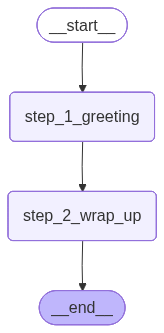

In [6]:
#Visualising 
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [14]:
#understanding reducers
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, END

#Step 1 : Defining the Custom Reducer Function
#Reducer takes two argument (current_value, new_value)
def append_unique_keywords(current: list[str] | None, new: list[str]) -> list[str]:
    if current is None:
        return new
    #Merge both list and keep unique items
    return list((current+new))

In [15]:
#State Schema
class ResearchState(TypedDict):
    #Using our reducer to accumulate updates
    keywords: Annotated[list[str], append_unique_keywords]

    #without reducer
    current_status: str

In [16]:
#Defining the nodes
def Google_Search_Node(state: ResearchState):
    print("--Running Google Search Node--")
    return{
        "keywords": ["machine learning", "ai"],
        "current_status": "Searching Google Completed"
    }

def Wikipedia_Search_Node(state: ResearchState):
    print("--Running Wikipedia Node--")
    return{
        "keywords": ["ai", "neural networks"], #ai word should be accumulated due to duplicacy
        "current_status": "Searching Wikipedia Completed"
    }

In [17]:
workflow = StateGraph(ResearchState)

#Addinng Nodes
workflow.add_node("google", Google_Search_Node)
workflow.add_node("wikipedia", Wikipedia_Search_Node)

#Adding Edges
workflow.set_entry_point("google")
workflow.add_edge("google", "wikipedia")
workflow.add_edge("wikipedia", END)

#Compiling the graph
app = workflow.compile()

In [18]:
#Running the graph
initial_state = {"keywords": [], "current_status": "Starting"}
final_output = app.invoke(initial_state)

print("\n---Final State Output---")
print("Keywords:", final_output["keywords"])
print("Status:", final_output["current_status"])


--Running Google Search Node--
--Running Wikipedia Node--

---Final State Output---
Keywords: ['machine learning', 'ai', 'ai', 'neural networks']
Status: Searching Wikipedia Completed


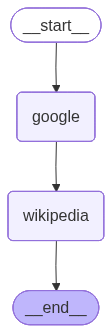

In [13]:
#As we can see the ai gets accumulated and not replaced but the status gets overridden

#Visualizing the Graph
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))